<a href="https://colab.research.google.com/github/kbletsa/Machine-Learning---Generative-Replay/blob/main/Hybrid_Mark_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy

# **Configuration**

In [ ]:
BATCH_SIZE = 64
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Κατέβασμα δεδομένων...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

Κατέβασμα δεδομένων...


100%|██████████| 9.91M/9.91M [00:00<00:00, 13.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 356kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.18MB/s]


# **Task Creation**

In [ ]:
def get_task_data(dataset, classes):
    targets = dataset.targets.numpy()
    mask = np.isin(targets, classes)
    indices = np.where(mask)[0]
    return Subset(dataset, indices)

tasks = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
train_loaders = []
test_loaders = []

for task_classes in tasks:
    task_train_subset = get_task_data(train_dataset, task_classes)
    task_test_subset = get_task_data(test_dataset, task_classes)
    train_loader = DataLoader(task_train_subset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(task_test_subset, batch_size=BATCH_SIZE, shuffle=False)
    train_loaders.append(train_loader)
    test_loaders.append(test_loader)

print("\n--- Έτοιμο το Split-MNIST! ---")
for i, loader in enumerate(train_loaders):
    print(f"Task {i+1} (Ψηφία {tasks[i]}): {len(loader.dataset)} εικόνες εκπαίδευσης")


--- Έτοιμο το Split-MNIST! ---
Task 1 (Ψηφία [0, 1]): 12665 εικόνες εκπαίδευσης
Task 2 (Ψηφία [2, 3]): 12089 εικόνες εκπαίδευσης
Task 3 (Ψηφία [4, 5]): 11263 εικόνες εκπαίδευσης
Task 4 (Ψηφία [6, 7]): 12183 εικόνες εκπαίδευσης
Task 5 (Ψηφία [8, 9]): 11800 εικόνες εκπαίδευσης


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Το μοντέλο θα τρέξει σε: {device}")

Το μοντέλο θα τρέξει σε: cuda


# **Model**

## *Classifier Configuration*

In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## *VAE Configuration*

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 400)
        self.fc21 = nn.Linear(400, latent_dim)
        self.fc22 = nn.Linear(400, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 28 * 28)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed_x = self.decode(z)
        return reconstructed_x, mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

## *Tiny Replay Buffer*

In [ ]:
class TinyReplayBuffer:
    def __init__(self, samples_per_task):
        self.samples_per_task = samples_per_task
        self.buffer_data = []
        self.buffer_targets = []

    def add_data(self, loader):
        all_data, all_targets = [], []
        for d, t in loader:
            all_data.append(d)
            all_targets.append(t)
        all_data = torch.cat(all_data)
        all_targets = torch.cat(all_targets)

        indices = torch.randperm(len(all_data))[:self.samples_per_task]
        self.buffer_data.append(all_data[indices])
        self.buffer_targets.append(all_targets[indices])

    def get_buffer_loader(self, batch_size):
        if len(self.buffer_data) == 0:
            return None
        b_data = torch.cat(self.buffer_data)
        b_targets = torch.cat(self.buffer_targets)
        dataset = TensorDataset(b_data, b_targets)
        return DataLoader(dataset, batch_size=batch_size, shuffle=True)

## *Evaluation Function*

In [ ]:
def evaluate_model(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct = 0
            total = 0
            for data, target in test_loaders[i]:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
            acc = 100 * correct / total
            accuracies.append(acc)
    return accuracies

# **Hybrid Replay Training Loop**

In [ ]:
EPOCHS_PER_TASK = 3
latent_dim = 20
criterion = nn.CrossEntropyLoss()

hybrid_classifier = SimpleClassifier().to(device)
hybrid_vae = VAE(latent_dim=latent_dim).to(device)

opt_hybrid_classifier = optim.Adam(hybrid_classifier.parameters(), lr=0.001)
opt_hybrid_vae = optim.Adam(hybrid_vae.parameters(), lr=0.001)

prev_hybrid_classifier = None
prev_hybrid_vae = None

tiny_buffer = TinyReplayBuffer(samples_per_task=50)

print("\n--- Ξεκινάει η Εκπαίδευση με HYBRID REPLAY (VAE + Tiny Buffer) ---")

for task_idx, train_loader in enumerate(train_loaders):
    print(f"\nΕκπαίδευση στο Task {task_idx + 1} (Ψηφία {tasks[task_idx]})...")
    hybrid_classifier.train()
    hybrid_vae.train()

    buffer_loader = tiny_buffer.get_buffer_loader(BATCH_SIZE)
    if buffer_loader is not None:
        buffer_iter = iter(buffer_loader)

    for epoch in range(EPOCHS_PER_TASK):
        for real_data, real_target in train_loader:
            real_data, real_target = real_data.to(device), real_target.to(device)

            combined_data_list = [real_data]
            combined_target_list = [real_target]

            if prev_hybrid_vae is not None and prev_hybrid_classifier is not None:
                with torch.no_grad():
                    z = torch.randn(real_data.size(0), latent_dim).to(device)
                    fake_data = prev_hybrid_vae.decode(z).view(-1, 1, 28, 28)

                    fake_outputs = prev_hybrid_classifier(fake_data)
                    _, fake_target = torch.max(fake_outputs.data, 1)

                combined_data_list.append(fake_data)
                combined_target_list.append(fake_target)

            if buffer_loader is not None:
                try:
                    mem_data, mem_target = next(buffer_iter)
                except StopIteration:
                    buffer_iter = iter(buffer_loader)
                    mem_data, mem_target = next(buffer_iter)

                mem_data, mem_target = mem_data.to(device), mem_target.to(device)
                combined_data_list.append(mem_data)
                combined_target_list.append(mem_target)

            combined_data = torch.cat(combined_data_list)
            combined_target = torch.cat(combined_target_list)

            opt_hybrid_classifier.zero_grad()
            outputs = hybrid_classifier(combined_data)
            loss_class = criterion(outputs, combined_target)
            loss_class.backward()
            opt_hybrid_classifier.step()

            opt_hybrid_vae.zero_grad()
            recon_batch, mu, logvar = hybrid_vae(combined_data)
            loss_vae = vae_loss_function(recon_batch, combined_data, mu, logvar)
            loss_vae.backward()
            opt_hybrid_vae.step()

    tiny_buffer.add_data(train_loader)

    accs = evaluate_model(hybrid_classifier, test_loaders, task_idx)
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}:")
    for i, acc in enumerate(accs):
        print(f" -> Ακρίβεια στο Task {i + 1}: {acc:.2f}%")

    prev_hybrid_classifier = copy.deepcopy(hybrid_classifier)
    prev_hybrid_classifier.eval()
    prev_hybrid_vae = copy.deepcopy(hybrid_vae)
    prev_hybrid_vae.eval()


--- Ξεκινάει η Εκπαίδευση με HYBRID REPLAY (VAE + Tiny Buffer) ---

Εκπαίδευση στο Task 1 (Ψηφία [0, 1])...
Αποτελέσματα μετά το Task 1:
 -> Ακρίβεια στο Task 1: 99.91%

Εκπαίδευση στο Task 2 (Ψηφία [2, 3])...
Αποτελέσματα μετά το Task 2:
 -> Ακρίβεια στο Task 1: 97.68%
 -> Ακρίβεια στο Task 2: 98.63%

Εκπαίδευση στο Task 3 (Ψηφία [4, 5])...
Αποτελέσματα μετά το Task 3:
 -> Ακρίβεια στο Task 1: 93.95%
 -> Ακρίβεια στο Task 2: 92.46%
 -> Ακρίβεια στο Task 3: 99.09%

Εκπαίδευση στο Task 4 (Ψηφία [6, 7])...
Αποτελέσματα μετά το Task 4:
 -> Ακρίβεια στο Task 1: 93.24%
 -> Ακρίβεια στο Task 2: 89.76%
 -> Ακρίβεια στο Task 3: 94.98%
 -> Ακρίβεια στο Task 4: 97.53%

Εκπαίδευση στο Task 5 (Ψηφία [8, 9])...
Αποτελέσματα μετά το Task 5:
 -> Ακρίβεια στο Task 1: 91.16%
 -> Ακρίβεια στο Task 2: 86.88%
 -> Ακρίβεια στο Task 3: 81.06%
 -> Ακρίβεια στο Task 4: 91.14%
 -> Ακρίβεια στο Task 5: 95.97%


# **Optical Results**

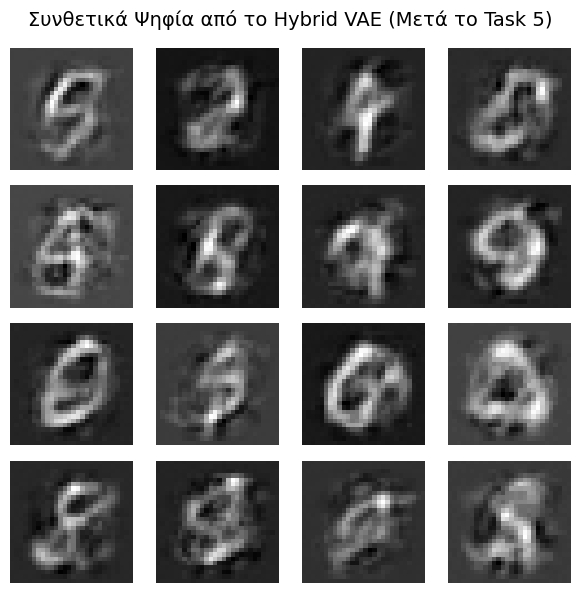

In [ ]:
hybrid_vae.eval()

with torch.no_grad():
    sample_noise = torch.randn(16, latent_dim).to(device)
    generated_images = hybrid_vae.decode(sample_noise).cpu()

generated_images = generated_images.view(16, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle('Συνθετικά Ψηφία από το Hybrid VAE (Μετά το Task 5)', fontsize=14)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i].numpy(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

# **Metrics**

In [ ]:
def calculate_continual_learning_metrics(accuracy_matrix):
    N = len(accuracy_matrix)
    forgetting = []
    bwt = []

    for j in range(N - 1):
        max_acc_past = max([accuracy_matrix[i][j] for i in range(j, N - 1)])
        final_acc = accuracy_matrix[N-1][j]

        f_j = max_acc_past - final_acc
        forgetting.append(f_j)

        initial_acc = accuracy_matrix[j][j]
        bwt_j = final_acc - initial_acc
        bwt.append(bwt_j)

    avg_forgetting = sum(forgetting) / len(forgetting)
    avg_bwt = sum(bwt) / len(bwt)

    print("=== ΜΕΤΡΙΚΕΣ HYBRID CONTINUAL LEARNING ===")
    print(f"Μέση Λήθη (Average Forgetting): {avg_forgetting:.2f}% ")
    print(f"Μεταφορά Γνώσης (Backward Transfer): {avg_bwt:.2f}% ")

hybrid_results = [
    [99.91],                                         # Task 1
    [97.97, 98.73],                                  # Task 2
    [96.36, 93.78, 98.19],                           # Task 3
    [89.98, 91.19, 95.57, 97.33],                    # Task 4
    [78.87, 86.43, 72.68, 91.24, 97.33]              # Task 5
]

calculate_continual_learning_metrics(hybrid_results)

=== ΜΕΤΡΙΚΕΣ HYBRID CONTINUAL LEARNING ===
Μέση Λήθη (Average Forgetting): 16.23% 
Μεταφορά Γνώσης (Backward Transfer): -16.23% 


# **Trade-off Study**

In [ ]:
def run_buffer_ablation_study(buffer_sizes=[0, 10, 25, 50, 100]):
    ablation_results = {}

    for size in buffer_sizes:
        print(f"\n" + "="*50)
        print(f"ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΟΣ: Buffer Size = {size} εικόνες/task")
        print("="*50)

        hybrid_classifier = SimpleClassifier().to(device)
        hybrid_vae = VAE(latent_dim=20).to(device)

        opt_hybrid_classifier = optim.Adam(hybrid_classifier.parameters(), lr=0.001)
        opt_hybrid_vae = optim.Adam(hybrid_vae.parameters(), lr=0.001)

        prev_hybrid_classifier = None
        prev_hybrid_vae = None

        tiny_buffer = TinyReplayBuffer(samples_per_task=size)

        accuracy_matrix = []

        for task_idx, train_loader in enumerate(train_loaders):
            hybrid_classifier.train()
            hybrid_vae.train()

            buffer_loader = tiny_buffer.get_buffer_loader(BATCH_SIZE)
            if buffer_loader is not None:
                buffer_iter = iter(buffer_loader)

            for epoch in range(EPOCHS_PER_TASK):
                for real_data, real_target in train_loader:
                    real_data, real_target = real_data.to(device), real_target.to(device)

                    combined_data_list = [real_data]
                    combined_target_list = [real_target]

                    if prev_hybrid_vae is not None and prev_hybrid_classifier is not None:
                        with torch.no_grad():
                            z = torch.randn(real_data.size(0), 20).to(device)
                            fake_data = prev_hybrid_vae.decode(z).view(-1, 1, 28, 28)
                            fake_outputs = prev_hybrid_classifier(fake_data)
                            _, fake_target = torch.max(fake_outputs.data, 1)
                        combined_data_list.append(fake_data)
                        combined_target_list.append(fake_target)

                    if buffer_loader is not None and size > 0:
                        try:
                            mem_data, mem_target = next(buffer_iter)
                        except StopIteration:
                            buffer_iter = iter(buffer_loader)
                            mem_data, mem_target = next(buffer_iter)
                        mem_data, mem_target = mem_data.to(device), mem_target.to(device)
                        combined_data_list.append(mem_data)
                        combined_target_list.append(mem_target)

                    combined_data = torch.cat(combined_data_list)
                    combined_target = torch.cat(combined_target_list)

                    opt_hybrid_classifier.zero_grad()
                    outputs = hybrid_classifier(combined_data)
                    loss_class = criterion(outputs, combined_target)
                    loss_class.backward()
                    opt_hybrid_classifier.step()

                    opt_hybrid_vae.zero_grad()
                    recon_batch, mu, logvar = hybrid_vae(combined_data)
                    loss_vae = vae_loss_function(recon_batch, combined_data, mu, logvar)
                    loss_vae.backward()
                    opt_hybrid_vae.step()

            if size > 0:
                tiny_buffer.add_data(train_loader)

            accs = evaluate_model(hybrid_classifier, test_loaders, task_idx)
            accuracy_matrix.append(accs)

            prev_hybrid_classifier = copy.deepcopy(hybrid_classifier)
            prev_hybrid_classifier.eval()
            prev_hybrid_vae = copy.deepcopy(hybrid_vae)
            prev_hybrid_vae.eval()


        gen_params = sum(p.numel() for p in hybrid_vae.parameters() if p.requires_grad)
        gen_mb = (gen_params * 4) / (1024 ** 2)

        total_images = 5 * size
        buffer_params = total_images * 784
        buffer_mb = (buffer_params * 4) / (1024 ** 2)

        total_memory_mb = gen_mb + buffer_mb

        N = len(accuracy_matrix)
        forgetting = []
        for j in range(N - 1):
            max_acc_past = max([accuracy_matrix[i][j] for i in range(j, N - 1)])
            final_acc = accuracy_matrix[N-1][j]
            forgetting.append(max_acc_past - final_acc)

        avg_forgetting = sum(forgetting) / len(forgetting)

        ablation_results[size] = {
            'memory_mb': total_memory_mb,
            'forgetting': avg_forgetting
        }

        print(f"\n[ΑΠΟΤΕΛΕΣΜΑΤΑ ΓΙΑ BUFFER SIZE: {size}]")
        print(f"-> Συνολική Μνήμη: {total_memory_mb:.2f} MB (Μοντέλο: {gen_mb:.2f} MB + Buffer: {buffer_mb:.2f} MB)")
        print(f"-> Average Forgetting: {avg_forgetting:.2f}%")

    return ablation_results

final_tradeoff_results = run_buffer_ablation_study([0, 10, 25, 50, 100])


ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΟΣ: Buffer Size = 0 εικόνες/task

[ΑΠΟΤΕΛΕΣΜΑΤΑ ΓΙΑ BUFFER SIZE: 0]
-> Συνολική Μνήμη: 2.49 MB (Μοντέλο: 2.49 MB + Buffer: 0.00 MB)
-> Average Forgetting: 44.43%

ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΟΣ: Buffer Size = 10 εικόνες/task

[ΑΠΟΤΕΛΕΣΜΑΤΑ ΓΙΑ BUFFER SIZE: 10]
-> Συνολική Μνήμη: 2.64 MB (Μοντέλο: 2.49 MB + Buffer: 0.15 MB)
-> Average Forgetting: 26.98%

ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΟΣ: Buffer Size = 25 εικόνες/task

[ΑΠΟΤΕΛΕΣΜΑΤΑ ΓΙΑ BUFFER SIZE: 25]
-> Συνολική Μνήμη: 2.86 MB (Μοντέλο: 2.49 MB + Buffer: 0.37 MB)
-> Average Forgetting: 17.68%

ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΟΣ: Buffer Size = 50 εικόνες/task

[ΑΠΟΤΕΛΕΣΜΑΤΑ ΓΙΑ BUFFER SIZE: 50]
-> Συνολική Μνήμη: 3.24 MB (Μοντέλο: 2.49 MB + Buffer: 0.75 MB)
-> Average Forgetting: 17.13%

ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΟΣ: Buffer Size = 100 εικόνες/task

[ΑΠΟΤΕΛΕΣΜΑΤΑ ΓΙΑ BUFFER SIZE: 100]
-> Συνολική Μνήμη: 3.99 MB (Μοντέλο: 2.49 MB + Buffer: 1.50 MB)
-> Average Forgetting: 8.91%
